# Pip & Import

In [45]:
import timm
import time
import os
import cv2
from tqdm import tqdm
import numpy as np
import pandas as pd
import torch
import torchvision
import collections
from sklearn import preprocessing
from timm.optim import create_optimizer_v2
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

# Data Processing

In [46]:
df_data = pd.read_csv('permeability.csv')
df_data.describe()

,index,Angle,Porosity,Surface_Area,Permeability_X,Unnamed: 5,Unnamed: 6,0.119982935,22.465265
count,1924.000000,1824.000000,1824.000000,1824.000000,1924.000000,0.0,0.0,0.0,0.0
mean,962.500000,90.000000,66.517154,6805.157895,3.640631,NaN,NaN,NaN,NaN
std,555.555278,54.787276,5.990983,1422.116151,4.279242,NaN,NaN,NaN,NaN
min,1.000000,0.000000,51.087952,3938.000000,0.119983,NaN,NaN,NaN,NaN
25%,481.750000,40.000000,63.696289,5576.750000,1.165519,NaN,NaN,NaN,NaN
50%,962.500000,90.000000,66.909027,7077.000000,2.246153,NaN,NaN,NaN,NaN
75%,1443.250000,140.000000,69.255447,8130.250000,4.578778,NaN,NaN,NaN,NaN
max,1924.000000,180.000000,81.900024,9029.000000,58.096134,NaN,NaN,NaN,NaN


In [47]:
min_max_scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
x_minmax =df_data[['Permeability_X']]# min_max_scaler.fit_transform(df_data[['Permeability_X']])
df_data['label'] = x_minmax
df_data.describe()

,index,Angle,Porosity,Surface_Area,Permeability_X,Unnamed: 5,Unnamed: 6,0.119982935,22.465265,label
count,1924.000000,1824.000000,1824.000000,1824.000000,1924.000000,0.0,0.0,0.0,0.0,1924.000000
mean,962.500000,90.000000,66.517154,6805.157895,3.640631,NaN,NaN,NaN,NaN,3.640631
std,555.555278,54.787276,5.990983,1422.116151,4.279242,NaN,NaN,NaN,NaN,4.279242
min,1.000000,0.000000,51.087952,3938.000000,0.119983,NaN,NaN,NaN,NaN,0.119983
25%,481.750000,40.000000,63.696289,5576.750000,1.165519,NaN,NaN,NaN,NaN,1.165519
50%,962.500000,90.000000,66.909027,7077.000000,2.246153,NaN,NaN,NaN,NaN,2.246153
75%,1443.250000,140.000000,69.255447,8130.250000,4.578778,NaN,NaN,NaN,NaN,4.578778
max,1924.000000,180.000000,81.900024,9029.000000,58.096134,NaN,NaN,NaN,NaN,58.096134


In [48]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, imgs_dir: str, labels: dict, transform=None):
        self.dataset = []
        for img_name, label in labels.items():
            img_path = os.path.join(imgs_dir, img_name)
            if os.path.exists(img_path):
                self.dataset.append((img_path, label))
            else:
                print(f"Warning: Image {img_path} does not exist")
        self.transform = transform

    def __getitem__(self, index):
        img_path, label = self.dataset[index]
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise ValueError(f"Error: Failed to read image {img_path}")

        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # transform
        if self.transform is not None:
            img = self.transform(img)
            #print(img.shape)
        return img, label

    def __len__(self):
        return len(self.dataset)

In [49]:
dict_labels = {}
for i, x in df_data.iterrows():
    filename = str(int(x.loc['index']))+'.tiff'
    label = x['label']
    dict_labels[filename] = float(label)
len(dict_labels)

1924

In [50]:
transform = torchvision.transforms.Compose([
  torchvision.transforms.ToTensor(),
  torchvision.transforms.Resize([224, 224]),
])

In [51]:
dataset = MyDataset('elliptical', dict_labels, transform=transform)
total_count = dataset.__len__()

test_count = int(0.2 * total_count)
valid_count = int(0.2 * total_count)
train_count = total_count - test_count - valid_count
train_dataset, valid_dataset, test_dataset = torch.utils.data.random_split(
    dataset, (train_count, valid_count, test_count), generator=torch.Generator().manual_seed(42)
)
print('Total: {}, Train: {}, Vali: {}, Test: {}'.format(total_count,train_count,valid_count, test_count))

Total: 1924, Train: 1156, Vali: 384, Test: 384


In [52]:
batch_size = 64
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=0,
    shuffle=True
    #prefetch_factor=0
)

valid_loader = torch.utils.data.DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=0,
    shuffle=False
    #prefetch_factor=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=0,
    shuffle=False
    #prefetch_factor=0
)

# Train & Test Function

In [53]:
import os
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import r2_score

def train_model(model, output_path, train_loader, valid_loader, num_epochs, optimizer, ce, patience=100):
    train_losses = []
    valid_losses = []
    valid_r2 = []
    epoch_times = []
    best_r2 = -100
    early_stopping = 0

    if not os.path.exists(output_path):
        os.makedirs(output_path)

    for epoch in range(num_epochs):
        start_time = time.time()
        losses = []

        model.train()
        for inputs, targets in tqdm(train_loader):
            inputs = inputs.to(torch.device(device))
            targets = targets.type(torch.float).to(torch.device(device))
            outputs = model(inputs).squeeze()
            loss = ce(outputs, targets)
            losses.append(loss)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_losses.append((sum(losses) / len(losses)).cpu().tolist())

        model.eval()
        labels = []
        preds = []
        losses = []

        with torch.no_grad():
            for inputs, targets in tqdm(valid_loader):
                inputs = inputs.to(torch.device(device))
                targets = targets.type(torch.float).to(torch.device(device))
                outputs = model(inputs).squeeze()
                loss = ce(outputs, targets)
                losses.append(loss)
                labels.append(targets)
                preds.append(outputs)

        valid_losses.append((sum(losses) / len(losses)).cpu().tolist())
        labels = torch.cat(labels, dim=0)
        preds = torch.cat(preds, dim=0)
        r2 = r2_score(labels.cpu().numpy(), preds.cpu().numpy())
        valid_r2.append(r2)

        end_time = time.time()
        epoch_time = end_time - start_time
        epoch_times.append(epoch_time)

        if r2 > best_r2:
            best_r2 = r2
            early_stopping = 0
            torch.save(model.state_dict(), os.path.join(output_path, 'best.pth'))
        else:
            early_stopping += 1

        print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} | "
              f"Valid Loss: {valid_losses[-1]:.4f} | R2 Score: {r2:.4f} | Epoch Time: {epoch_time:.2f} seconds")

        if early_stopping > patience:
            break

    df_train_log = pd.DataFrame.from_dict({
        'train_loss': train_losses,
        'val_loss': valid_losses,
        'val_r2': valid_r2,
        'epoch_times': epoch_times
    })
    df_train_log.to_csv(os.path.join(output_path, 'train_log.csv'), index=False)

    # Plot training curves
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(valid_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(valid_r2, label='Validation R2')
    plt.xlabel('Epoch')
    plt.ylabel('R² Score')
    plt.title('R² Curve')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'training_plot.png'))
    plt.close()


In [55]:
import os
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error


def test_model(model, output_path, test_loader, device='cuda'):
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    test_labels = []
    test_preds = []

    model.eval()
    with torch.no_grad():
        start_time = time.time()
        for inputs, targets in tqdm(test_loader, desc='Testing'):
            inputs = inputs.to(device)
            targets = targets.type(torch.float).to(device)
            outputs = model(inputs)

            test_labels.append(targets.detach().cpu())
            test_preds.append(outputs.detach().cpu())

        end_time = time.time()
        test_time = end_time - start_time

    test_labels = torch.cat(test_labels, dim=0).squeeze()
    test_preds = torch.cat(test_preds, dim=0).squeeze()

    # Compute R² Score
    # Compute R² and MSE
    r2 = r2_score(test_labels.numpy(), test_preds.numpy())
    mse = mean_squared_error(test_labels.numpy(), test_preds.numpy())

    print(f'Test R²: {r2:.4f}, Test MSE: {mse:.4f}, Test time: {test_time:.2f} seconds')

    # Save predictions
    df_test_result = pd.DataFrame({
        'labels': test_labels.tolist(),
        'predicts': test_preds.tolist()
    })
    df_test_result.to_csv(os.path.join(output_path, 'test_result.csv'), index=False)

    # Plot R² scatter plot with MSE
    plt.figure(figsize=(6, 6))
    plt.scatter(test_labels, test_preds, alpha=0.5, label=f'R² = {r2:.4f}\nMSE = {mse:.4f}')
    plt.plot([test_labels.min(), test_labels.max()],
            [test_labels.min(), test_labels.max()],
            'r--', label='Ideal')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title('Predicted vs. True Labels')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'r2_plot.png'))
    plt.show()  # Optional: show the plot if running interactively


# Model

# Swin Transformmer

In [56]:
model_name = 'swin_base_patch4_window7_224'
model_swin = timm.create_model(model_name, pretrained=True, num_classes=1, global_pool='avg')#
o = model_swin(torch.randn(2, 3, 224, 224))
print(f'OUT shape: {o.shape}')

OUT shape: torch.Size([2, 1])


In [57]:
new_fc = torch.nn.Sequential(collections.OrderedDict([
    ('relu', torch.nn.ReLU()),# GELU ReLU
    ('dropout', torch.nn.Dropout(0.1)),
    ('fc', torch.nn.Linear(1024, 1))
    ]))

model_swin.head.fc = new_fc
print(model_swin.head)

ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Sequential(
    (relu): ReLU()
    (dropout): Dropout(p=0.1, inplace=False)
    (fc): Linear(in_features=1024, out_features=1, bias=True)
  )
  (flatten): Identity()
)


In [58]:
swin_path = './'+ model_name+'_'+ str(400)

path = os.path.join(swin_path, 'best.pth')
if os.path.exists(path):
    model_swin.load_state_dict(torch.load(path))
    print("model load successful")

In [59]:
print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.cuda.set_device('cuda:{}'.format(0))
model_swin = model_swin.to(device)

num_epochs = 50
optimizer = torch.optim.Adam(model_swin.parameters(), lr=1e-4, betas=(0.9, 0.999), eps=1e-08, weight_decay=1e-4)
ce = torch.nn.HuberLoss()

True


In [ ]:
train_model(model_swin, swin_path, train_loader, valid_loader, num_epochs, optimizer, ce)

100%|██████████| 6/6 [00:41<00:00,  6.85s/it]


Epoch 1/50 | Train Loss: 1.6286 | Valid Loss: 0.9077 | R2 Score: 0.5999 | Epoch Time: 400.87 seconds


 68%|██████▊   | 13/19 [04:12<01:54, 19.01s/it]

Testing: 100%|██████████| 12/12 [00:05<00:00,  2.17it/s]


Test R²: 0.9078, Test MSE: 0.0019, Test time: 5.54 seconds


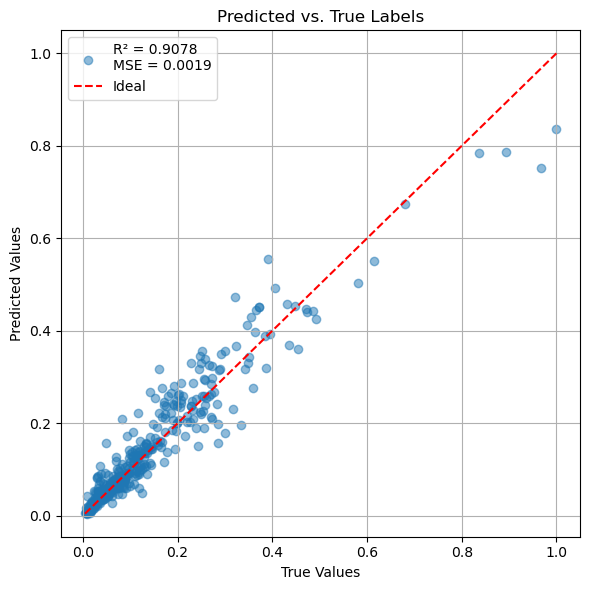

In [ ]:
test_model(model_swin, swin_path, test_loader)